In [1]:
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
from srm.utils import open_icechunk

## Get data

In [2]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
)
var = "pr"
scenario = "historical"
ens = "r3i1p1f1"
branch = "v0.11.0"

In [14]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2")
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
# print(root.tree())

{'v0.8.0', 'v0.11.1', 'main', 'v0.10.0', 'v0.7.0', 'v0.11.0'}


In [25]:
lat_slice = slice(-35, -22)
lon_slice = slice(16, 33)

In [26]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var].sel(lat=lat_slice, lon=lon_slice)

debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var].sel(lat=lat_slice, lon=lon_slice)

In [16]:
lat_slice = slice(-35, -22)
lon_slice = slice(16, 33)
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.where(obs_fine["time.year"] >= 1978, drop=True)
obs_fine_subset = obs_fine.sel(lat=lat_slice, lon=lon_slice)

obs_fine = rechunk(obs_fine_subset, pattern="full_space").persist()
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()
coarse_debiased_finegrid = coarse_debiased.interp(
    lon=obs_fine["lon"],
    lat=obs_fine["lat"],
    method="nearest",
).compute()

fine = rechunk(
    debiased_downscaled, pattern="full_space"
).persist()  # -> (time≈25, lat=-1, lon=-1), ~100 MB/chunk
coarsened_debiased_downscaled = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine, da_coarse_grid=coarse_debiased
)

/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/opt/coiled/env/lib/python3.13/site-packages/dask/_task_spec.py:768: Runtime

# Compare different steps of the process

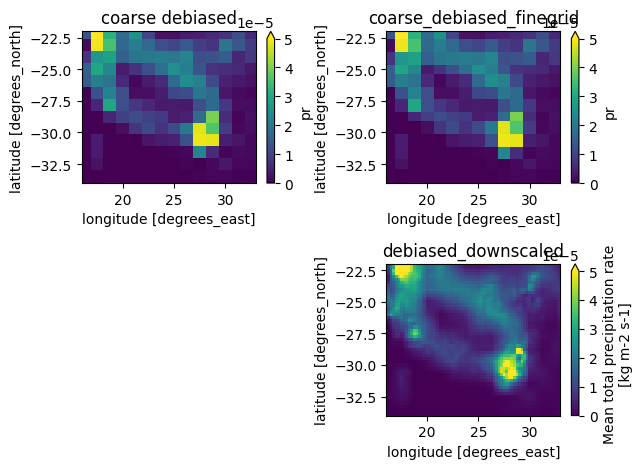

In [6]:
vmax=5e-5
plt.subplot(2, 2, 1)
coarse_debiased.isel(time=0).plot(vmax=vmax)
plt.ylim([-34, -22])
plt.xlim([16, 33])
plt.gca().set_title('coarse debiased')

plt.subplot(2, 2, 2)
coarse_debiased_finegrid.isel(time=0).plot(vmax=vmax)
plt.ylim([-34, -22])
plt.xlim([16, 33])
plt.gca().set_title('coarse_debiased_finegrid')

plt.subplot(2, 2, 4)
debiased_downscaled.isel(time=0).plot(vmax=vmax)
plt.ylim([-34, -22])
plt.xlim([16, 33])
plt.gca().set_title('debiased_downscaled')
plt.tight_layout()

# Do evaluation

In [27]:
# Two outputs on fine grid
debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean().compute()
coarse_debiased_finegrid_doy = coarse_debiased_finegrid.groupby("time.dayofyear").mean().compute()

# Two outputs on coarse grid
coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean().compute()
coarsened_debiased_downscaled_doy = (
    coarsened_debiased_downscaled.groupby("time.dayofyear").mean().compute()
)

In [17]:
obs_fine_doy = obs_fine_subset.groupby("time.dayofyear").mean().compute()
obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean().compute()

In [19]:
metrics_obsfine_outputfine = disagg_test_calculate_metrics(
    x=obs_fine_doy, y=debiased_downscaled_doy, time_dim="dayofyear"
)
metrics_obsfine_outputcoarse = disagg_test_calculate_metrics(
    x=obs_fine_doy, y=coarse_debiased_finegrid_doy, time_dim="dayofyear"
)

metrics_obscoarse_outputfine = disagg_test_calculate_metrics(
    x=obs_coarse_doy, y=coarsened_debiased_downscaled_doy, time_dim="dayofyear"
)
metrics_obscoarse_outputcoarse = disagg_test_calculate_metrics(
    x=obs_coarse_doy, y=coarse_debiased_doy, time_dim="dayofyear"
)

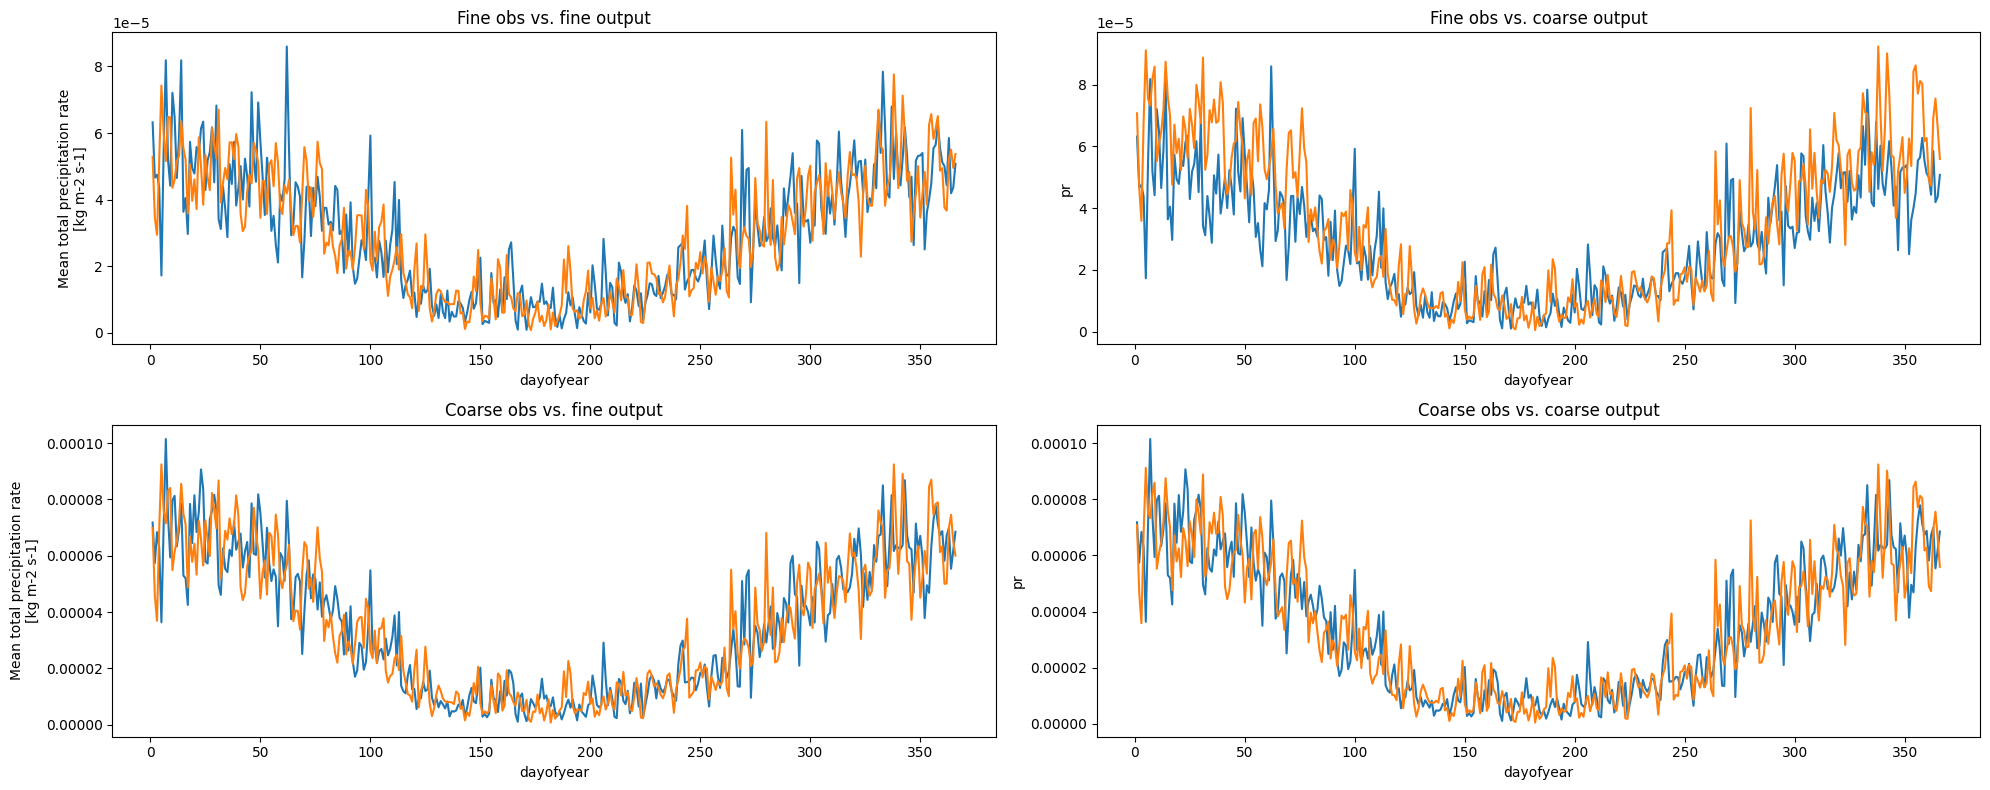

In [28]:
pt_lat = -31
pt_lon = 29
plt.figure(figsize=(20, 8))
plt.subplot(2, 2, 1)
(obs_fine_doy.sel(lat=pt_lat, lon=pt_lon).plot())
(debiased_downscaled_doy.sel(lat=pt_lat, lon=pt_lon).plot())
plt.title("Fine obs vs. fine output")
plt.subplot(2, 2, 2)
(obs_fine_doy.sel(lat=pt_lat, lon=pt_lon).plot())
(coarse_debiased_finegrid_doy.sel(lat=pt_lat, lon=pt_lon).plot())
plt.title("Fine obs vs. coarse output")
plt.subplot(2, 2, 3)
(obs_coarse_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
(coarsened_debiased_downscaled_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
plt.title("Coarse obs vs. fine output")
plt.subplot(2, 2, 4)
(obs_coarse_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
(coarse_debiased_doy.sel(lat=pt_lat, lon=pt_lon, method="nearest").plot())
plt.title("Coarse obs vs. coarse output")
plt.tight_layout()

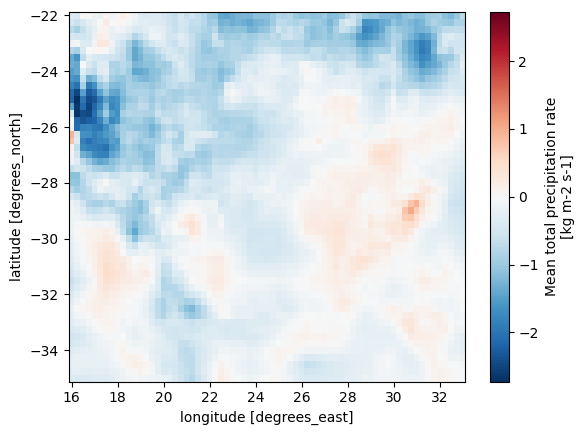

In [38]:
((debiased_downscaled.mean(dim='time')-obs_fine_subset.mean(dim='time'))/obs_fine_subset.mean(dim='time')*100).plot()

(array([9.23649e+05, 3.09517e+05, 8.50700e+04, 1.64640e+04, 2.81700e+03,
        6.26000e+02, 2.19000e+02, 6.20000e+01, 2.90000e+01, 9.00000e+00]),
 array([0.00000000e+00, 2.09584596e-05, 4.19169191e-05, 6.28753769e-05,
        8.38338383e-05, 1.04792300e-04, 1.25750754e-04, 1.46709222e-04,
        1.67667677e-04, 1.88626131e-04, 2.09584599e-04]),
 <BarContainer object of 10 artists>)

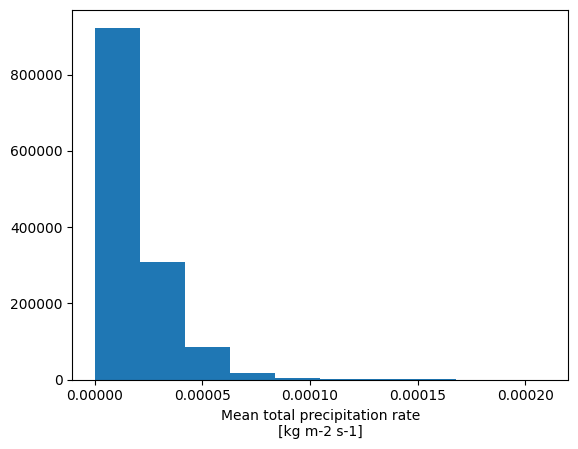

In [35]:
debiased_downscaled_doy.

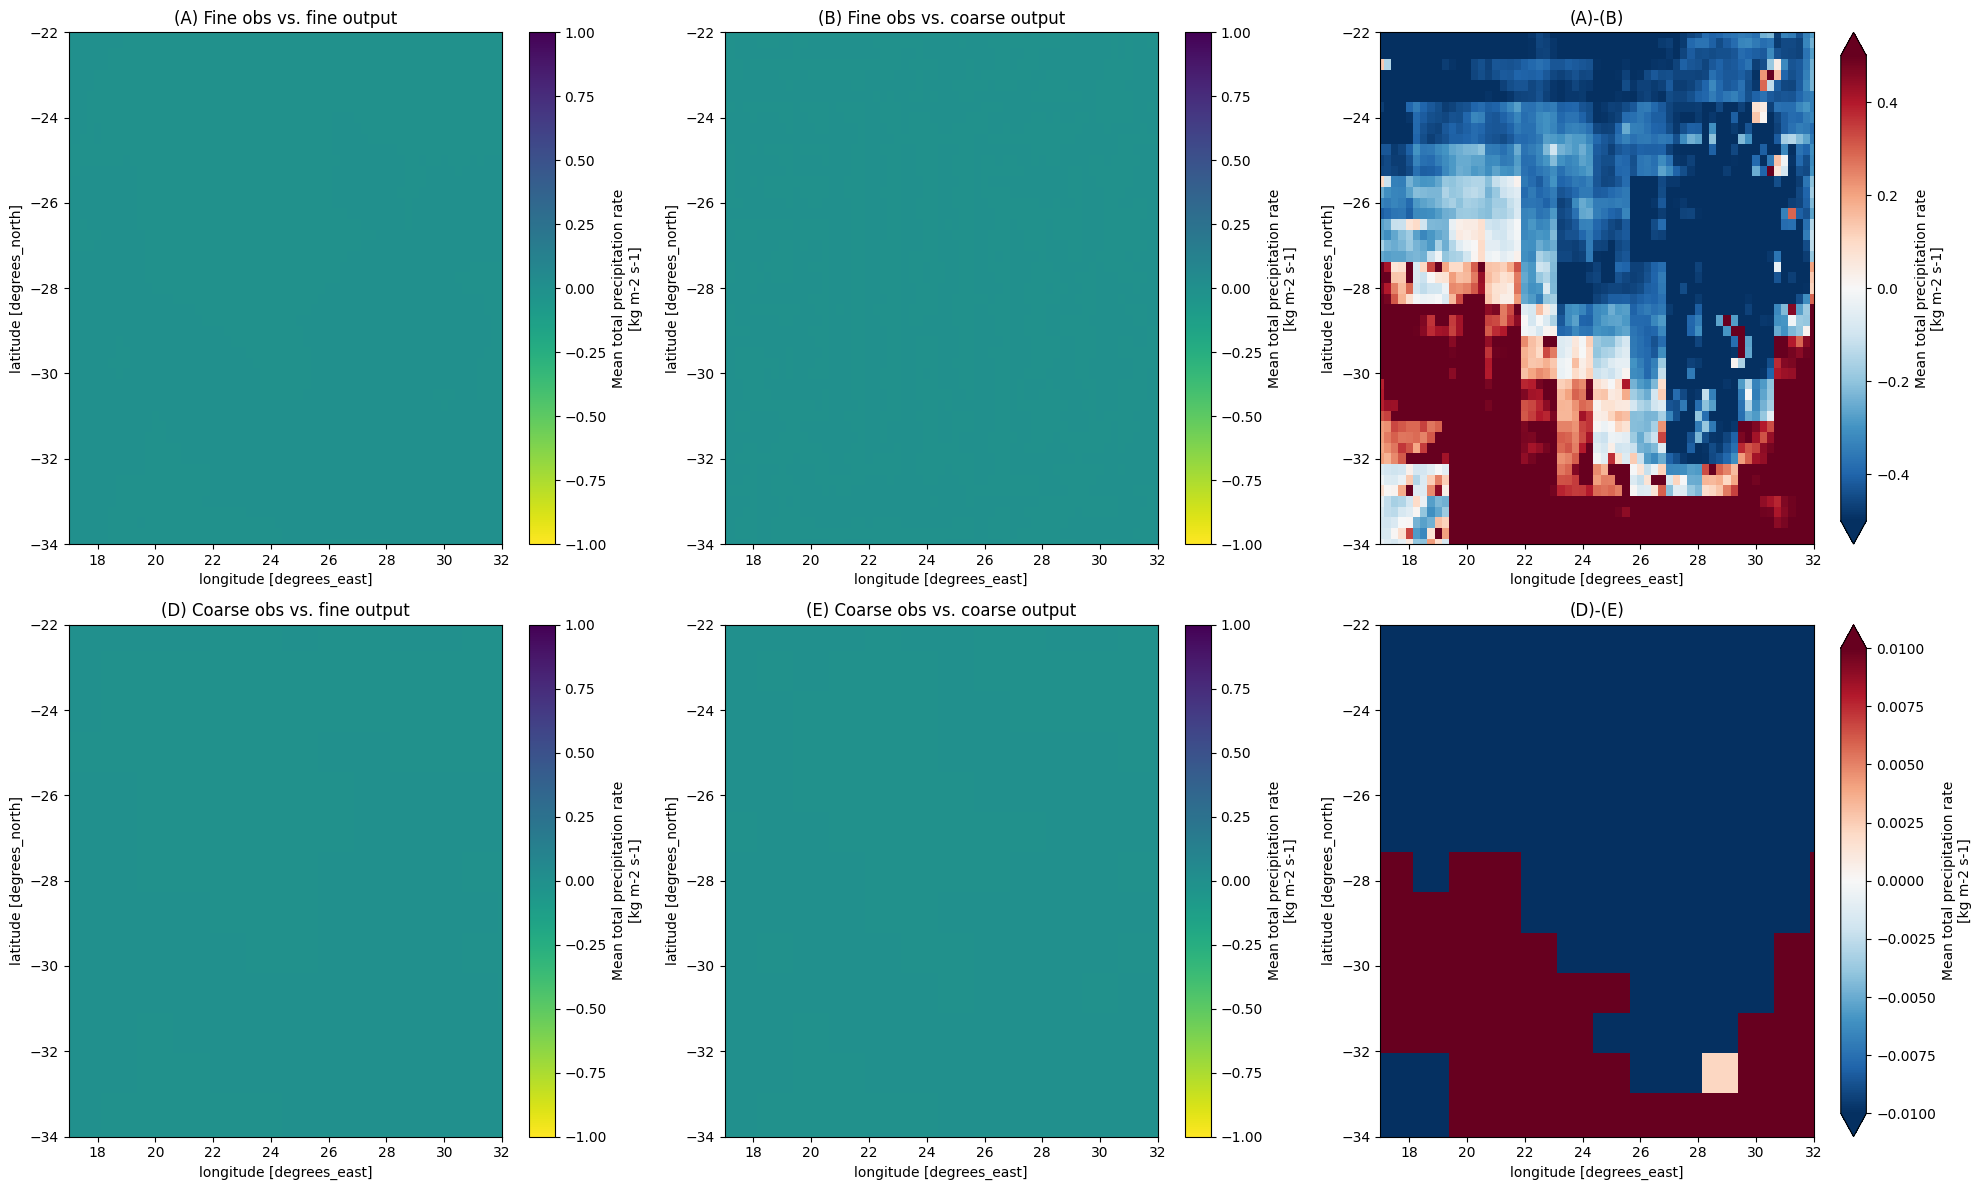

In [31]:
vmin = -1
vmax = 1


def format_subplot():
    plt.ylim([-34, -22])
    plt.xlim([17, 32])

metric = 'bias'
plt.figure(figsize=(20, 12))
plt.subplot(2, 3, 1)
metrics_obsfine_outputfine[metric].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(A) Fine obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 2)
metrics_obsfine_outputcoarse[metric].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(B) Fine obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 3)
(metrics_obsfine_outputfine[metric] - metrics_obsfine_outputcoarse["r2_oneone"]).plot(vmax=0.5)
plt.title("(A)-(B)")
format_subplot()
plt.subplot(2, 3, 4)
metrics_obscoarse_outputfine[metric].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(D) Coarse obs vs. fine output")
format_subplot()
plt.subplot(2, 3, 5)
metrics_obscoarse_outputcoarse[metric].plot(vmax=vmax, vmin=vmin, cmap=plt.cm.viridis_r)
plt.title("(E) Coarse obs vs. coarse output")
format_subplot()
plt.subplot(2, 3, 6)
(metrics_obscoarse_outputfine[metric] - metrics_obscoarse_outputcoarse["r2_oneone"]).plot(
    vmax=0.01
)
plt.title("(D)-(E)")
format_subplot()
plt.tight_layout()

# CDF comparison across locations

Note: `obs_fine` above was subset to the South Africa training region, so we
reload it on the full (global) domain here to compare against all 20
locations in `srm.plotting.locations`. No coarse-grid interpolation is
performed — `coarse_debiased` is plotted on its native grid.

In [36]:
from srm.plotting import locations, plot_cdf_by_location

obs_fine_global = catalog.get("ERA5").to_xarray()[var]
obs_fine_global = obs_fine_global.sel(time=slice('1978', '2014'))

In [44]:
locations = {'Cape Town': (-33.9221, 18.4231)}

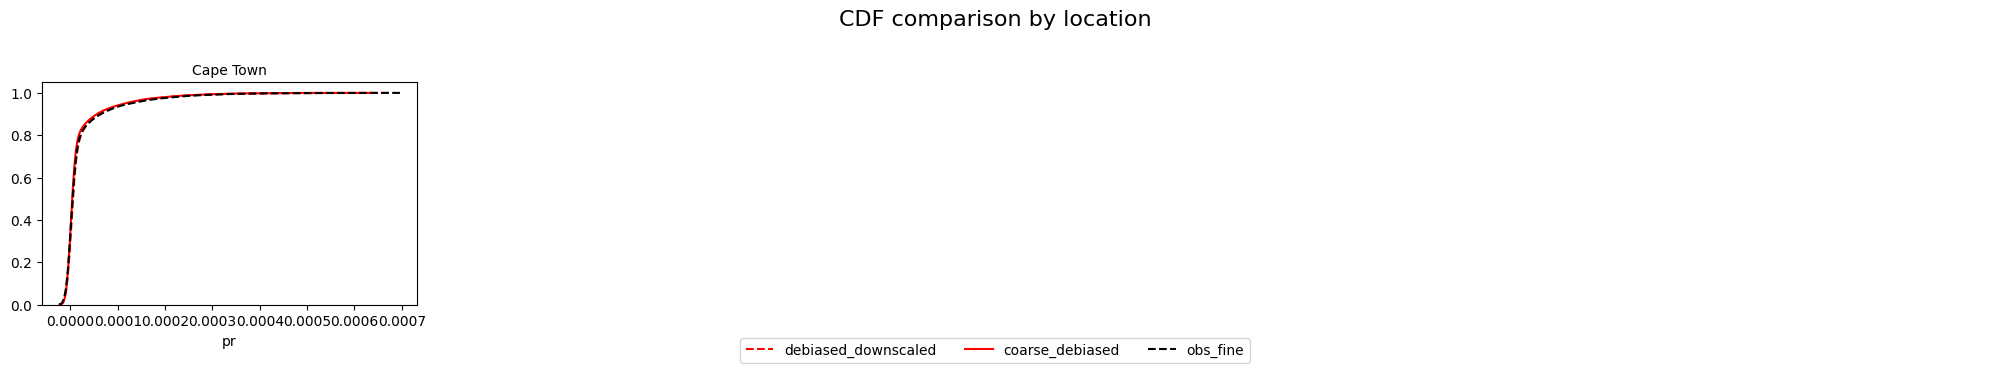

In [46]:
fig = plot_cdf_by_location(
    debiased_downscaled=debiased_downscaled,
    coarse_debiased=coarse_debiased,
    obs_fine=obs_fine_global,
    locations=locations,
    var=var,
)